# Alignment & Rationality Notebook

This notebook contains rationality parameter estimation and alignment score computation using data from the HMC/NUTS model.

In [8]:
import pickle
import numpy as np
import os

# Change working directory to project root
# The notebook is in Writeups/notebooks/, so we need to go up 2 levels
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Try to find the project root by looking for data/processed/pymc_posterior_estimates.pkl
possible_roots = [
    current_dir,  # If already in project root
    os.path.abspath(os.path.join(current_dir, '..', '..')),  # If in Writeups/notebooks/
    os.path.abspath(os.path.join(current_dir, '..')),  # If in Writeups/
    '/Users/nalinguest/Desktop/Agentik Project'  # Absolute fallback
]

project_root = None
for root in possible_roots:
    test_path = os.path.join(root, 'data', 'processed', 'pymc_posterior_estimates.pkl')
    if os.path.exists(test_path):
        project_root = root
        os.chdir(project_root)
        print(f"✓ Found project root: {project_root}")
        print(f"✓ Changed working directory to: {os.getcwd()}")
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root. Tried:\n" + 
        "\n".join([f"  - {r}" for r in possible_roots]) +
        f"\nPlease ensure the file exists at: data/processed/pymc_posterior_estimates.pkl"
    )

# posterior estimates (includes means, stds, AND all actual samples)
with open('data/processed/pymc_posterior_estimates.pkl', 'rb') as f:
    pymc_results = pickle.load(f)

# Summary statistics
beta_mean = pymc_results['beta_mean']
beta_std = pymc_results['beta_std']
intercept_mean = pymc_results['intercept_mean']
intercept_std = pymc_results['intercept_std']

# ALL actual posterior samples (all draws from all chains)
beta_all_samples = pymc_results['beta_all_samples']  # Shape: (n_chains * n_draws, n_features)
intercept_all_samples = pymc_results['intercept_all_samples']  # Shape: (n_chains * n_draws,)

feature_names = pymc_results['feature_names']
n_chains = pymc_results['n_chains']
n_draws = pymc_results['n_draws']

print("Loaded posterior estimates:")
print(f"Beta mean shape: {beta_mean.shape}")
print(f"Beta ALL samples shape: {beta_all_samples.shape} ({n_chains} chains × {n_draws} draws)")
print(f"Intercept ALL samples shape: {intercept_all_samples.shape}")
print(f"Intercept mean: {intercept_mean:.4f}")
print(f"Number of features: {len(feature_names)}")
print(f"\nExample: Access all beta values for feature 0:")
print(f"  beta_all_samples[:, 0] shape: {beta_all_samples[:, 0].shape}")
print(f"  First 5 values: {beta_all_samples[:5, 0]}")

Current working directory: /Users/nalinguest/Desktop/Agentik Project
✓ Found project root: /Users/nalinguest/Desktop/Agentik Project
✓ Changed working directory to: /Users/nalinguest/Desktop/Agentik Project
Loaded posterior estimates:
Beta mean shape: (66,)
Beta ALL samples shape: (8000, 66) (4 chains × 2000 draws)
Intercept ALL samples shape: (8000,)
Intercept mean: -2.3205
Number of features: 66

Example: Access all beta values for feature 0:
  beta_all_samples[:, 0] shape: (8000,)
  First 5 values: [0.35061807 0.5025789  0.49347664 0.21474191 0.65030717]


In [9]:
# Load validation data for temperature scaling
import pickle
import numpy as np
import pandas as pd

# Load validation features and targets (files are named X_vas, y_va but we use X_val, y_val as variables)
X_val = pd.DataFrame(np.load('data/processed/X_vas.npy'))
y_val = np.load('data/processed/y_va.npy')

# Load feature names to set columns
with open('data/processed/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

X_val.columns = feature_names
X_val_array = X_val.to_numpy(dtype=np.float64)

print(f"Validation data loaded:")
print(f"X_val shape: {X_val_array.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"Class distribution: {np.bincount(y_val)}")


Validation data loaded:
X_val shape: (2322, 66)
y_val shape: (2322,)
Class distribution: [1941  381]


In [10]:
# Compute utilities/logits using posterior mean parameters
# For binary classification: U_i,0 = 0, U_i,1 = η_i = intercept + X_i^T β
# Using sigmoid directly (equivalent to softmax with 2 classes where U_0=0)

eta_val = intercept_mean + X_val_array @ beta_mean  # Shape: (n_samples,)

# For softmax formulation: logits = [0, η_i] for each sample
# But since we're using sigmoid, we can work directly with η_i
logits_val = eta_val

print(f"Logits computed:")
print(f"Logits (η) shape: {logits_val.shape}")
print(f"Logits range: [{logits_val.min():.4f}, {logits_val.max():.4f}]")
print(f"Logits mean: {logits_val.mean():.4f}")


Logits computed:
Logits (η) shape: (2322,)
Logits range: [-6.6585, 28.3096]
Logits mean: -2.1527


In [11]:
# Negative Log-Likelihood function
# We minimize NLL (equivalently maximize log-likelihood) on validation data
# Correct formulation: P(y_i=1 | x_i) = σ(λ * η_i) where λ is rationality/inverse temperature

def negative_log_likelihood(lambda_rationality, logits, y_true):
    """
    Compute negative log-likelihood for rationality-scaled binary classification.
    Using sigmoid: p = σ(λ * η_i) where λ is rationality parameter (inverse temperature)
    
    Log-likelihood: ℓ(λ) = Σ[λ y_i η_i - log(1 + exp(λ η_i))]
    NLL(λ) = -ℓ(λ) = Σ[log(1 + exp(λ η_i)) - λ y_i η_i]
    
    Args:
        lambda_rationality: Rationality parameter λ (inverse temperature, must be > 0)
        logits: Raw logits η_i = intercept + X^T β (shape: n_samples,)
        y_true: True binary labels (shape: n_samples,)
    
    Returns:
        Negative log-likelihood (scalar)
    """
    # Enforce λ > 0
    lambda_rationality = max(lambda_rationality, 1e-8)
    
    # Scale logits by rationality: z = λ * η_i
    z = lambda_rationality * logits
    
    # Numerically stable computation of log(1 + exp(z))
    # Use logaddexp(0, z) = log(1 + exp(z)) for stability
    log1p_exp_z = np.logaddexp(0, z)
    
    # NLL(λ) = Σ[log(1 + exp(λ η_i)) - λ y_i η_i]
    nll = np.sum(log1p_exp_z - lambda_rationality * y_true * logits)
    
    return nll


In [12]:
# Gradient of Negative Log-Likelihood
# For NLL(λ) = Σ[log(1 + exp(λ η_i)) - λ y_i η_i]

def gradient_nll(lambda_rationality, logits, y_true):
    """
    Compute gradient of NLL w.r.t. λ.
    
    d/dλ NLL(λ) = d/dλ Σ[log(1 + exp(λ η_i)) - λ y_i η_i]
                 = Σ[(exp(λ η_i) / (1 + exp(λ η_i))) * η_i - y_i η_i]
                 = Σ[(p_i - y_i) * η_i]
    
    where p_i = σ(λ η_i) = exp(λ η_i) / (1 + exp(λ η_i))
    
    Args:
        lambda_rationality: Rationality parameter λ (must be > 0)
        logits: Raw logits η_i (shape: n_samples,)
        y_true: True binary labels (shape: n_samples,)
    
    Returns:
        Gradient of NLL w.r.t. λ (scalar)
    """
    # Enforce λ > 0
    lambda_rationality = max(lambda_rationality, 1e-8)
    
    # Scale logits: z = λ * η_i
    z = lambda_rationality * logits
    
    # Numerically stable sigmoid: p = σ(z) = 1 / (1 + exp(-z))
    # For large negative z, use: p = exp(z) / (1 + exp(z))
    # Use logaddexp trick for stability
    p = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    
    # Gradient: d/dλ NLL = Σ[(p_i - y_i) * η_i]
    grad = np.sum((p - y_true) * logits)
    
    return grad


In [13]:
# Hessian of Negative Log-Likelihood
# For NLL(λ) = Σ[log(1 + exp(λ η_i)) - λ y_i η_i]

def hessian_nll(lambda_rationality, logits, y_true):
    """
    Compute Hessian (second derivative) of NLL w.r.t. λ.
    
    d²/dλ² NLL(λ) = d/dλ Σ[(p_i - y_i) * η_i]
                   = Σ[d/dλ p_i * η_i]
                   = Σ[p_i(1-p_i) * η_i²]
    
    where p_i = σ(λ η_i), so d/dλ p_i = p_i(1-p_i) * η_i
    
    Note: This is always ≥ 0, ensuring convexity.
    
    Args:
        lambda_rationality: Rationality parameter λ (must be > 0)
        logits: Raw logits η_i (shape: n_samples,)
        y_true: True binary labels (shape: n_samples,)
    
    Returns:
        Hessian of NLL w.r.t. λ (scalar, should be ≥ 0)
    """
    # Enforce λ > 0
    lambda_rationality = max(lambda_rationality, 1e-8)
    
    # Scale logits: z = λ * η_i
    z = lambda_rationality * logits
    
    # Numerically stable sigmoid: p = σ(z)
    p = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    
    # Hessian: d²/dλ² NLL = Σ[p_i(1-p_i) * η_i²]
    hess = np.sum(p * (1 - p) * logits ** 2)
    
    return hess


In [14]:
# Newton's Method for Rationality Parameter Optimization

def newton_method_temperature(logits, y_true, lambda_init=1.0, tol=1e-6, max_iter=100):
    """
    Find optimal rationality parameter λ using Newton's method to minimize NLL.
    
    Newton update: λ_new = λ_old - grad / hess
    
    Args:
        logits: Raw logits η_i from model (shape: n_samples,)
        y_true: True binary labels (shape: n_samples,)
        lambda_init: Initial guess for λ (default: 1.0)
        tol: Convergence tolerance
        max_iter: Maximum iterations
    
    Returns:
        lambda_hat: Optimal rationality parameter
        history: Dictionary with optimization history
    """
    lambda_curr = max(lambda_init, 1e-8)  # Ensure positive
    history = {'lambda': [lambda_curr], 'nll': [], 'grad': [], 'hess': []}
    
    for i in range(max_iter):
        # Compute objective, gradient, and hessian
        nll = negative_log_likelihood(lambda_curr, logits, y_true)
        grad = gradient_nll(lambda_curr, logits, y_true)
        hess = hessian_nll(lambda_curr, logits, y_true)
        
        history['nll'].append(nll)
        history['grad'].append(grad)
        history['hess'].append(hess)
        
        # Print iteration diagnostics
        print(f"Iter {i+1:3d}: λ={lambda_curr:.6f}, NLL={nll:.6f}, grad={grad:.6e}, hess={hess:.6e}")
        
        # Check convergence
        if abs(grad) < tol:
            print(f"\nConverged after {i+1} iterations")
            break
        
        # Newton step: λ_new = λ_old - grad / hess
        # With damping: if step increases NLL, halve step size
        if hess > 1e-10:  # Hessian should be positive (convex)
            step = grad / hess
            lambda_new = lambda_curr - step
            
            # Enforce λ > 0
            lambda_new = max(lambda_new, 1e-8)
            
            # Check if step increases NLL (damping)
            nll_new = negative_log_likelihood(lambda_new, logits, y_true)
            damping_factor = 1.0
            max_damping_iter = 10
            
            while nll_new > nll and damping_factor > 1e-6 and max_damping_iter > 0:
                damping_factor *= 0.5
                lambda_new = lambda_curr - damping_factor * step
                lambda_new = max(lambda_new, 1e-8)
                nll_new = negative_log_likelihood(lambda_new, logits, y_true)
                max_damping_iter -= 1
            
            lambda_curr = lambda_new
        else:
            # If hessian is too small, use small gradient descent step
            print(f"  Warning: Hessian too small ({hess:.2e}), using small gradient step")
            lambda_curr = max(lambda_curr - 0.01 * grad, 1e-8)
        
        history['lambda'].append(lambda_curr)
    
    return lambda_curr, history


In [15]:
# Grid check: Evaluate NLL over a range of λ values to confirm Newton solution
print("Grid check: Evaluating NLL over λ ∈ [0.05, 5.0]...")
lambda_grid = np.linspace(0.05, 5.0, 100)
nll_grid = np.array([negative_log_likelihood(lam, logits_val, y_val) for lam in lambda_grid])
lambda_grid_min = lambda_grid[np.argmin(nll_grid)]

print(f"Grid minimum: λ = {lambda_grid_min:.6f}, NLL = {np.min(nll_grid):.6f}")

# Run Newton's method to find optimal rationality parameter
print("\n" + "="*60)
print("Finding optimal rationality parameter λ using Newton's method...")
print("="*60)
lambda_hat, history = newton_method_temperature(logits_val, y_val, lambda_init=1.0)

print(f"\n{'='*60}")
print(f"Results:")
print(f"{'='*60}")
print(f"Optimal rationality parameter λ̂ = {lambda_hat:.6f}")
print(f"Final negative log-likelihood: {history['nll'][-1]:.6f}")
print(f"Final gradient: {history['grad'][-1]:.6e}")
print(f"Final hessian: {history['hess'][-1]:.6e}")
print(f"\nGrid check comparison:")
print(f"  Grid minimum λ: {lambda_grid_min:.6f}")
print(f"  Newton λ̂:        {lambda_hat:.6f}")
print(f"  Difference:      {abs(lambda_hat - lambda_grid_min):.6f}")


Grid check: Evaluating NLL over λ ∈ [0.05, 5.0]...
Grid minimum: λ = 0.950000, NLL = 717.282370

Finding optimal rationality parameter λ using Newton's method...
Iter   1: λ=1.000000, NLL=717.339010, grad=2.122264e+01, hess=7.740698e+02
Iter   2: λ=0.972583, NLL=717.054083, grad=-6.604306e-01, hess=8.227701e+02
Iter   3: λ=0.973386, NLL=717.053818, grad=-5.905194e-04, hess=8.212993e+02
Iter   4: λ=0.973386, NLL=717.053818, grad=-4.732215e-10, hess=8.212979e+02

Converged after 4 iterations

Results:
Optimal rationality parameter λ̂ = 0.973386
Final negative log-likelihood: 717.053818
Final gradient: -4.732215e-10
Final hessian: 8.212979e+02

Grid check comparison:
  Grid minimum λ: 0.950000
  Newton λ̂:        0.973386
  Difference:      0.023386


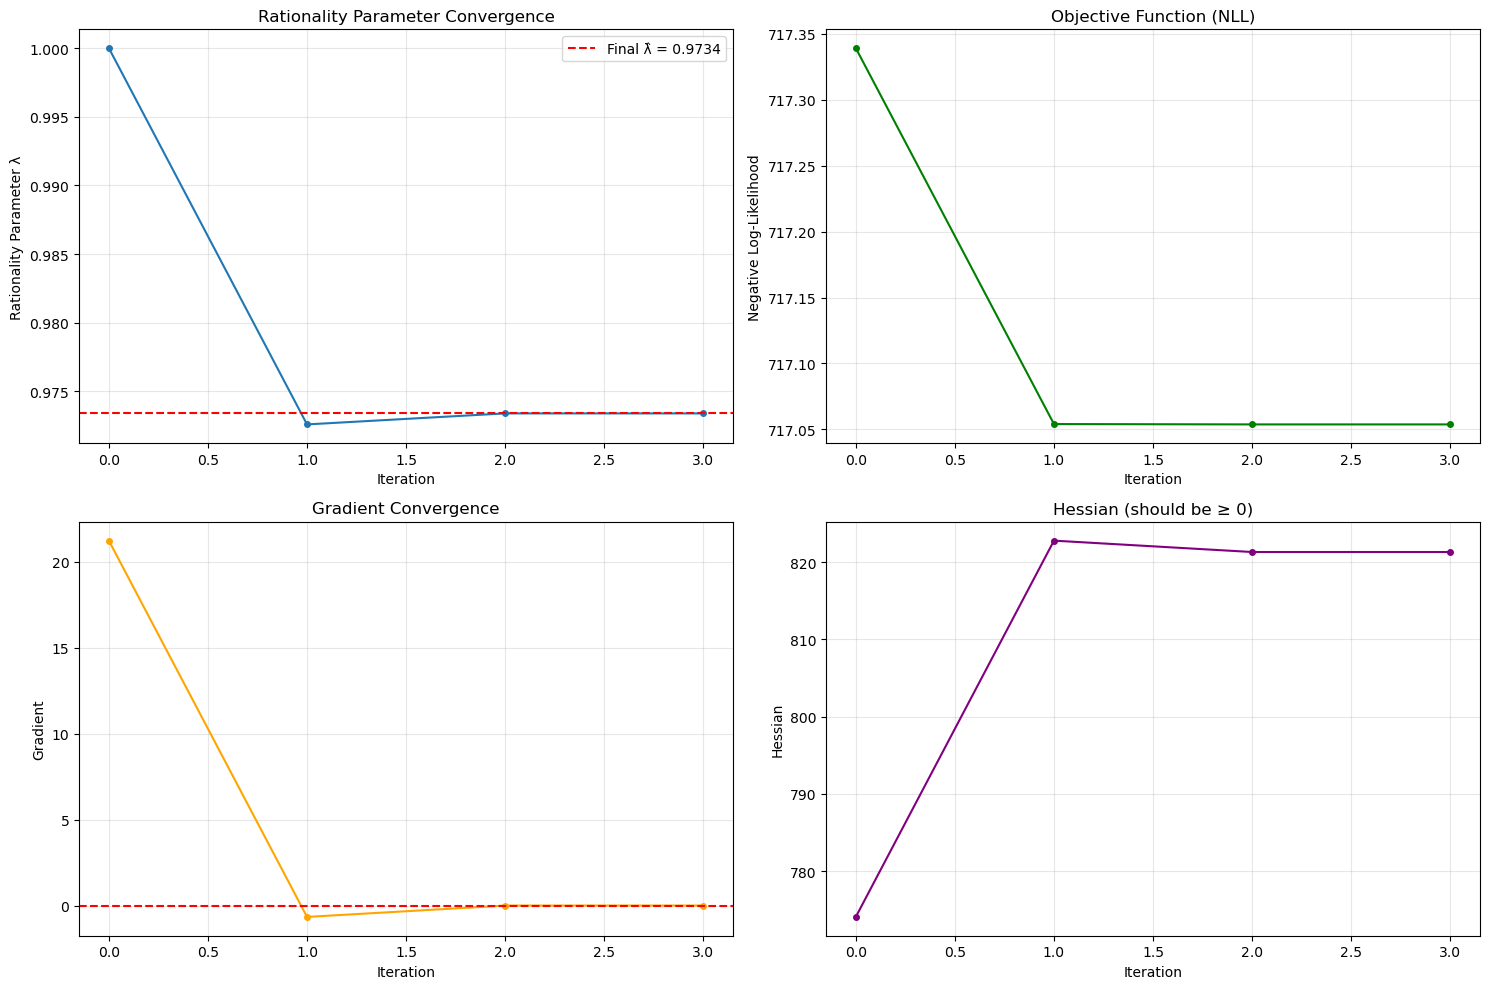

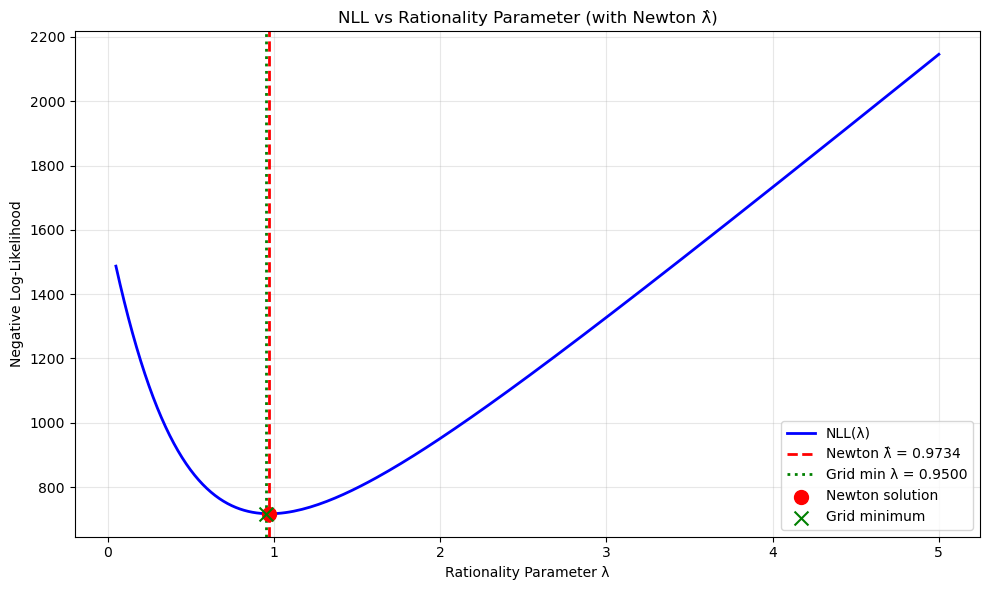


Optimization Summary:
  Initial λ: 1.000000
  Final λ̂: 0.973386
  Change: -0.026614
  Iterations: 4
  Final NLL: 717.053818
  Grid minimum NLL: 717.282370
  NLL difference: 2.285515e-01


In [16]:
# Visualize optimization progress
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Lambda convergence
axes[0, 0].plot(history['lambda'], marker='o', markersize=4)
axes[0, 0].axhline(y=lambda_hat, color='r', linestyle='--', label=f'Final λ̂ = {lambda_hat:.4f}')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Rationality Parameter λ')
axes[0, 0].set_title('Rationality Parameter Convergence')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Negative log-likelihood
axes[0, 1].plot(history['nll'], marker='o', markersize=4, color='green')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Negative Log-Likelihood')
axes[0, 1].set_title('Objective Function (NLL)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Gradient
axes[1, 0].plot(history['grad'], marker='o', markersize=4, color='orange')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Gradient')
axes[1, 0].set_title('Gradient Convergence')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Hessian
axes[1, 1].plot(history['hess'], marker='o', markersize=4, color='purple')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Hessian')
axes[1, 1].set_title('Hessian (should be ≥ 0)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot NLL vs λ on a grid (sanity check)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
lambda_grid_plot = np.linspace(0.05, 5.0, 200)
nll_grid_plot = np.array([negative_log_likelihood(lam, logits_val, y_val) for lam in lambda_grid_plot])
ax.plot(lambda_grid_plot, nll_grid_plot, 'b-', linewidth=2, label='NLL(λ)')
ax.axvline(x=lambda_hat, color='r', linestyle='--', linewidth=2, label=f'Newton λ̂ = {lambda_hat:.4f}')
ax.axvline(x=lambda_grid_min, color='g', linestyle=':', linewidth=2, label=f'Grid min λ = {lambda_grid_min:.4f}')
ax.scatter([lambda_hat], [history['nll'][-1]], color='red', s=100, zorder=5, label='Newton solution')
ax.scatter([lambda_grid_min], [np.min(nll_grid)], color='green', s=100, zorder=5, marker='x', label='Grid minimum')
ax.set_xlabel('Rationality Parameter λ')
ax.set_ylabel('Negative Log-Likelihood')
ax.set_title('NLL vs Rationality Parameter (with Newton λ̂)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimization Summary:")
print(f"  Initial λ: {history['lambda'][0]:.6f}")
print(f"  Final λ̂: {lambda_hat:.6f}")
print(f"  Change: {lambda_hat - history['lambda'][0]:.6f}")
print(f"  Iterations: {len(history['nll'])}")
print(f"  Final NLL: {history['nll'][-1]:.6f}")
print(f"  Grid minimum NLL: {np.min(nll_grid):.6f}")
print(f"  NLL difference: {abs(history['nll'][-1] - np.min(nll_grid)):.6e}")


In [17]:
# Compare calibrated vs uncalibrated predictions
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

# Uncalibrated predictions (λ = 1.0): p = σ(1.0 * η_i) = σ(η_i)
p_uncalibrated = 1.0 / (1.0 + np.exp(-logits_val))

# Calibrated predictions (using optimal λ̂): p = σ(λ̂ * η_i)
p_calibrated = 1.0 / (1.0 + np.exp(-lambda_hat * logits_val))

# Compute metrics
print("Calibration Comparison:")
print(f"\nUncalibrated (λ = 1.0):")
print(f"  Log Loss: {log_loss(y_val, p_uncalibrated):.6f}")
print(f"  Brier Score: {brier_score_loss(y_val, p_uncalibrated):.6f}")
print(f"  AUC: {roc_auc_score(y_val, p_uncalibrated):.6f}")

print(f"\nCalibrated (λ̂ = {lambda_hat:.6f}):")
print(f"  Log Loss: {log_loss(y_val, p_calibrated):.6f}")
print(f"  Brier Score: {brier_score_loss(y_val, p_calibrated):.6f}")
print(f"  AUC: {roc_auc_score(y_val, p_calibrated):.6f}")

print(f"\nImprovement:")
print(f"  Log Loss reduction: {log_loss(y_val, p_uncalibrated) - log_loss(y_val, p_calibrated):.6f}")
print(f"  Brier Score reduction: {brier_score_loss(y_val, p_uncalibrated) - brier_score_loss(y_val, p_calibrated):.6f}")

# Interpretation
if lambda_hat > 1.0:
    print(f"\nInterpretation: λ̂ > 1 means the model was overconfident (too sharp).")
    print(f"  Temperature scaling makes predictions more conservative.")
elif lambda_hat < 1.0:
    print(f"\nInterpretation: λ̂ < 1 means the model was underconfident (too flat).")
    print(f"  Temperature scaling makes predictions sharper.")
else:
    print(f"\nInterpretation: λ̂ ≈ 1 means the model was well-calibrated.")


Calibration Comparison:

Uncalibrated (λ = 1.0):
  Log Loss: 0.308932
  Brier Score: 0.091418
  AUC: 0.884325

Calibrated (λ̂ = 0.973386):
  Log Loss: 0.308809
  Brier Score: 0.091322
  AUC: 0.884325

Improvement:
  Log Loss reduction: 0.000123
  Brier Score reduction: 0.000095

Interpretation: λ̂ < 1 means the model was underconfident (too flat).
  Temperature scaling makes predictions sharper.


In [18]:
# Save rationality temperature and calibration results
import os

os.makedirs('data/processed', exist_ok=True)

rationality_results = {
    'lambda_hat': lambda_hat,
    'optimization_history': history,
    'logits_validation': logits_val,
    'p_calibrated': p_calibrated,
    'p_uncalibrated': p_uncalibrated,
    'metrics': {
        'log_loss_uncalibrated': log_loss(y_val, p_uncalibrated),
        'log_loss_calibrated': log_loss(y_val, p_calibrated),
        'brier_uncalibrated': brier_score_loss(y_val, p_uncalibrated),
        'brier_calibrated': brier_score_loss(y_val, p_calibrated),
        'auc_uncalibrated': roc_auc_score(y_val, p_uncalibrated),
        'auc_calibrated': roc_auc_score(y_val, p_calibrated)
    }
}

with open('data/processed/rationality_temperature.pkl', 'wb') as f:
    pickle.dump(rationality_results, f)

print("Rationality temperature results saved!")
print(f"  Saved to: data/processed/rationality_temperature.pkl")
print(f"  Contains: λ̂, optimization history, calibrated predictions, and metrics")


Rationality temperature results saved!
  Saved to: data/processed/rationality_temperature.pkl
  Contains: λ̂, optimization history, calibrated predictions, and metrics


# Regret and Regret-based Alignment score 

In [19]:
# Step 1: Compute linear utility V_i = (E[β])ᵀ x_i
# Vectorized: V = X @ beta_mean

V = X_val_array @ beta_mean  # Shape: (n_samples,)

print("Step 1: Linear utility computed")
print(f"  V shape: {V.shape}")
print(f"  V range: [{V.min():.4f}, {V.max():.4f}]")
print(f"  V mean: {V.mean():.4f}")
print(f"  V std: {V.std():.4f}")

Step 1: Linear utility computed
  V shape: (2322,)
  V range: [-4.3380, 30.6301]
  V mean: 0.1678
  V std: 1.9992


In [20]:
# Step 2 & 3: Compute optimal and observed utilities
# Utilities defined as: U_i(1) = V_i, U_i(0) = 0

# Optimal utility: U_i* = max(V_i, 0)  (choose action 1 if V_i > 0, else 0)
U_star = np.maximum(V, 0.0)  # Shape: (n_samples,)

# Observed utility: U_iobs = y_i · V_i  (if y_i=1, get V_i; if y_i=0, get 0)
U_obs = y_val * V  # Shape: (n_samples,)

print("Step 3: Optimal and observed utilities computed")
print(f"  U_star shape: {U_star.shape}")
print(f"  U_star range: [{U_star.min():.4f}, {U_star.max():.4f}]")
print(f"  U_star mean: {U_star.mean():.4f}")
print(f"  U_obs shape: {U_obs.shape}")
print(f"  U_obs range: [{U_obs.min():.4f}, {U_obs.max():.4f}]")
print(f"  U_obs mean: {U_obs.mean():.4f}")

Step 3: Optimal and observed utilities computed
  U_star shape: (2322,)
  U_star range: [0.0000, 30.6301]
  U_star mean: 0.7016
  U_obs shape: (2322,)
  U_obs range: [-2.8295, 30.6301]
  U_obs mean: 0.4111


In [21]:
# Step 4: Compute regret R_i = U_i* - U_iobs

regret = U_star - U_obs  # Shape: (n_samples,)

# Clip regret at 0 to avoid numerical negatives (sanity check)
regret = np.maximum(regret, 0.0)

print("Step 4: Regret computed")
print(f"  Regret shape: {regret.shape}")
print(f"  Regret range: [{regret.min():.4f}, {regret.max():.4f}]")
print(f"  Regret mean: {regret.mean():.4f}")
print(f"  Number of zero regret (perfect alignment): {np.sum(regret == 0)}")
print(f"  Percentage of zero regret: {100 * np.mean(regret == 0):.2f}%")

# Sanity check: Verify R_i ≥ 0 for all rows
if np.any(regret < -1e-9):
    n_negative = np.sum(regret < -1e-9)
    print(f"  WARNING: Found {n_negative} regret values < -1e-9 (should be 0)")
    regret = np.maximum(regret, 0.0)  # Clip to ensure non-negative
else:
    print(f"  ✓ All regret values are non-negative (min = {regret.min():.2e})")

Step 4: Regret computed
  Regret shape: (2322,)
  Regret range: [0.0000, 13.8463]
  Regret mean: 0.2905
  Number of zero regret (perfect alignment): 1568
  Percentage of zero regret: 67.53%
  ✓ All regret values are non-negative (min = 0.00e+00)


In [22]:
# Step 5: Compute alignment score S_i = exp(−λ_hat · R_i)

S_align = np.exp(-lambda_hat * regret)  # Shape: (n_samples,)

print("Step 5: Alignment score computed")
print(f"  S_align shape: {S_align.shape}")
print(f"  S_align range: [{S_align.min():.6f}, {S_align.max():.6f}]")
print(f"  S_align mean: {S_align.mean():.6f}")
print(f"  S_align std: {S_align.std():.6f}")
print(f"  Perfect alignment (S=1.0): {np.sum(S_align == 1.0)} ({100*np.mean(S_align == 1.0):.2f}%)")

Step 5: Alignment score computed
  S_align shape: (2322,)
  S_align range: [0.000001, 1.000000]
  S_align mean: 0.852657
  S_align std: 0.261310
  Perfect alignment (S=1.0): 1568 (67.53%)


In [23]:
# Create results DataFrame with all computed metrics

results_df = pd.DataFrame({
    'V': V,
    'U_star': U_star,
    'U_obs': U_obs,
    'regret': regret,
    'S_align': S_align
}, index=X_val.index)

# Add context columns (y_val as Revenue)
results_df['Revenue'] = y_val

print("Results DataFrame created:")
print(f"  Shape: {results_df.shape}")
print(f"  Columns: {list(results_df.columns)}")

Results DataFrame created:
  Shape: (2322, 6)
  Columns: ['V', 'U_star', 'U_obs', 'regret', 'S_align', 'Revenue']


In [24]:
# Summary statistics and correlation analysis

print("="*60)
print("Summary Statistics")
print("="*60)

print("\nLinear Utility (V):")
print(f"  Mean: {V.mean():.6f}, Std: {V.std():.6f}")
print(f"  Min: {V.min():.6f}, Max: {V.max():.6f}, Median: {np.median(V):.6f}")

print("\nRegret (R):")
print(f"  Mean: {regret.mean():.6f}, Std: {regret.std():.6f}")
print(f"  Min: {regret.min():.6f}, Max: {regret.max():.6f}, Median: {np.median(regret):.6f}")
print(f"  Zero regret (perfect alignment): {np.sum(regret == 0)} ({100*np.mean(regret == 0):.2f}%)")

print("\nAlignment Score (S_align):")
print(f"  Mean: {S_align.mean():.6f}, Std: {S_align.std():.6f}")
print(f"  Min: {S_align.min():.6f}, Max: {S_align.max():.6f}, Median: {np.median(S_align):.6f}")
print(f"  Perfect alignment (S=1.0): {np.sum(S_align == 1.0)} ({100*np.mean(S_align == 1.0):.2f}%)")

print("\nCorrelation with Revenue:")
print(f"  V vs Revenue: {np.corrcoef(V, y_val)[0, 1]:.6f}")
print(f"  Regret vs Revenue: {np.corrcoef(regret, y_val)[0, 1]:.6f}")
print(f"  S_align vs Revenue: {np.corrcoef(S_align, y_val)[0, 1]:.6f}")

Summary Statistics

Linear Utility (V):
  Mean: 0.167767, Std: 1.999229
  Min: -4.338038, Max: 30.630095, Median: -0.093072

Regret (R):
  Mean: 0.290460, Std: 0.760686
  Min: 0.000000, Max: 13.846334, Median: 0.000000
  Zero regret (perfect alignment): 1568 (67.53%)

Alignment Score (S_align):
  Mean: 0.852657, Std: 0.261310
  Min: 0.000001, Max: 1.000000, Median: 1.000000
  Perfect alignment (S=1.0): 1568 (67.53%)

Correlation with Revenue:
  V vs Revenue: 0.518054
  Regret vs Revenue: -0.144106
  S_align vs Revenue: 0.202953


In [25]:
# Display results preview and descriptive statistics

print("="*60)
print("Results DataFrame Preview")
print("="*60)
print("\nFirst 10 rows:")
print(results_df.head(10))

print("\nDescriptive Statistics:")
print(results_df[["V", "regret", "S_align"]].describe())

Results DataFrame Preview

First 10 rows:
          V    U_star  U_obs    regret   S_align  Revenue
0 -0.699149  0.000000   -0.0  0.000000  1.000000        0
1 -0.154335  0.000000   -0.0  0.000000  1.000000        0
2  0.715332  0.715332    0.0  0.715332  0.498429        0
3 -1.782935  0.000000   -0.0  0.000000  1.000000        0
4 -0.424993  0.000000   -0.0  0.000000  1.000000        0
5 -0.004052  0.000000   -0.0  0.000000  1.000000        0
6 -0.656090  0.000000   -0.0  0.000000  1.000000        0
7 -0.314041  0.000000   -0.0  0.000000  1.000000        0
8 -1.483217  0.000000   -0.0  0.000000  1.000000        0
9  0.359768  0.359768    0.0  0.359768  0.704552        0

Descriptive Statistics:
                 V       regret      S_align
count  2322.000000  2322.000000  2322.000000
mean      0.167767     0.290460     0.852657
std       1.999659     0.760850     0.261366
min      -4.338038     0.000000     0.000001
25%      -0.839188     0.000000     0.782437
50%      -0.093072     0.

In [26]:
# Save results to files

os.makedirs('data/processed', exist_ok=True)

# Save to parquet (efficient binary format)
parquet_path = 'data/processed/alignment_metrics.parquet'
results_df.to_parquet(parquet_path, index=True)
print(f"✓ Saved to: {parquet_path}")

# Save to CSV for inspection
csv_path = 'data/processed/alignment_metrics.csv'
results_df.to_csv(csv_path, index=True)
print(f"✓ Saved to: {csv_path}")

print("\n" + "="*60)
print("✓ Regret and alignment metrics computed and saved successfully!")
print("="*60)

✓ Saved to: data/processed/alignment_metrics.parquet
✓ Saved to: data/processed/alignment_metrics.csv

✓ Regret and alignment metrics computed and saved successfully!


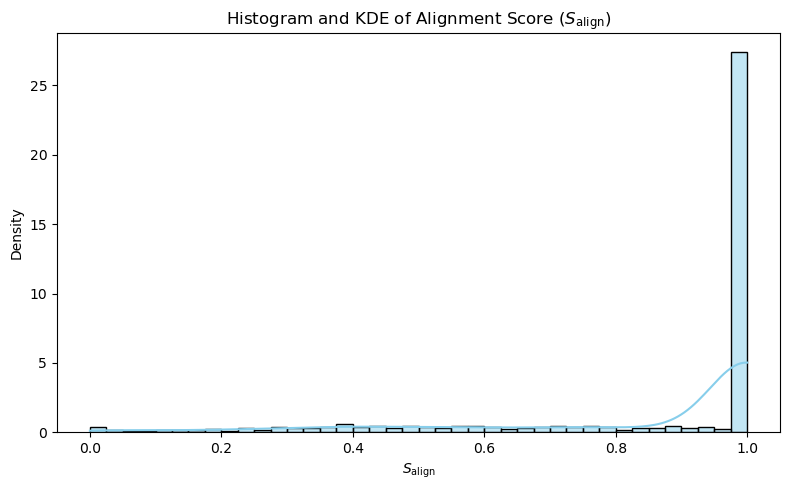


Alignment Score Summary:
  Mean:   0.852657
  Median: 1.000000
  10th percentile (bottom 10% level): 0.395394
  Min:    0.000001
  Max:    1.000000
  Std:    0.261310
  Fraction below 0.5: 14.34%
  Fraction above 0.9: 70.89%


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the histogram and KDE for S_align
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(S_align, kde=True, color="skyblue", bins=40, stat="density", ax=ax)
ax.set_title("Histogram and KDE of Alignment Score ($S_{\\mathrm{align}}$)")
ax.set_xlabel("$S_{\\mathrm{align}}$")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

# Summary statistics for S_align
mean_salign = np.mean(S_align)
median_salign = np.median(S_align)
bottom_10pct = np.percentile(S_align, 10)
print(f"\nAlignment Score Summary:")
print(f"  Mean:   {mean_salign:.6f}")
print(f"  Median: {median_salign:.6f}")
print(f"  10th percentile (bottom 10% level): {bottom_10pct:.6f}")
print(f"  Min:    {np.min(S_align):.6f}")
print(f"  Max:    {np.max(S_align):.6f}")
print(f"  Std:    {np.std(S_align):.6f}")
print(f"  Fraction below 0.5: {(np.mean(S_align < 0.5)*100):.2f}%")
print(f"  Fraction above 0.9: {(np.mean(S_align > 0.9)*100):.2f}%")



PILLAR 3 — Contextual Shifts

1. Weekend vs Weekday Analysis:
             mean  median  count
Weekend                         
False    0.852017     1.0   1755
True     0.854638     1.0    567


/var/folders/3g/39__grbn0fq4_w22vcrp4g940000gn/T/ipykernel_55121/815956507.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='Weekend', y='S_align', palette=['lightblue', 'lightcoral'])


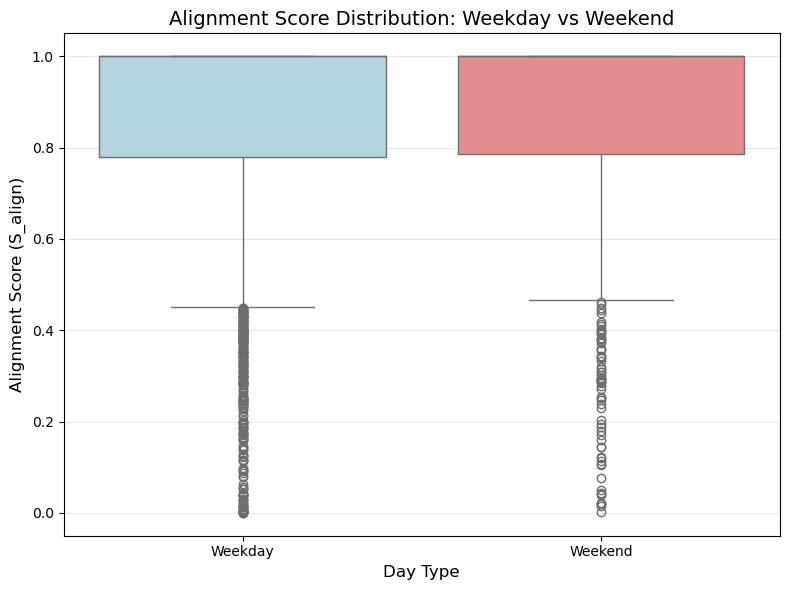


2. Month Analysis:
  Month      mean  median  count
1   Nov  0.856304     1.0   1399
0   Dec  0.847129     1.0    923


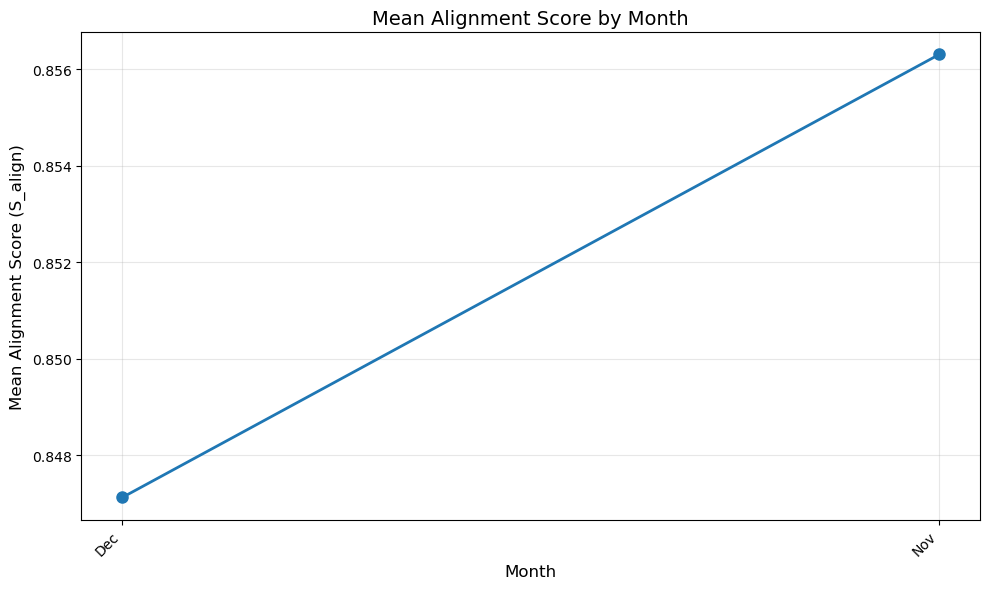


3. TrafficType Analysis:
    TrafficType      mean    median  count
9            15  0.942013  1.000000      5
10           20  0.909024  1.000000     58
3             6  0.871506  1.000000     58
6            10  0.865419  1.000000    165
1             2  0.856793  1.000000    989
0             1  0.854359  1.000000    431
8            13  0.842695  1.000000    113
2             3  0.840988  1.000000    269
5             8  0.828293  1.000000    151
7            11  0.807542  1.000000     73
4             7  0.802530  0.859663     10


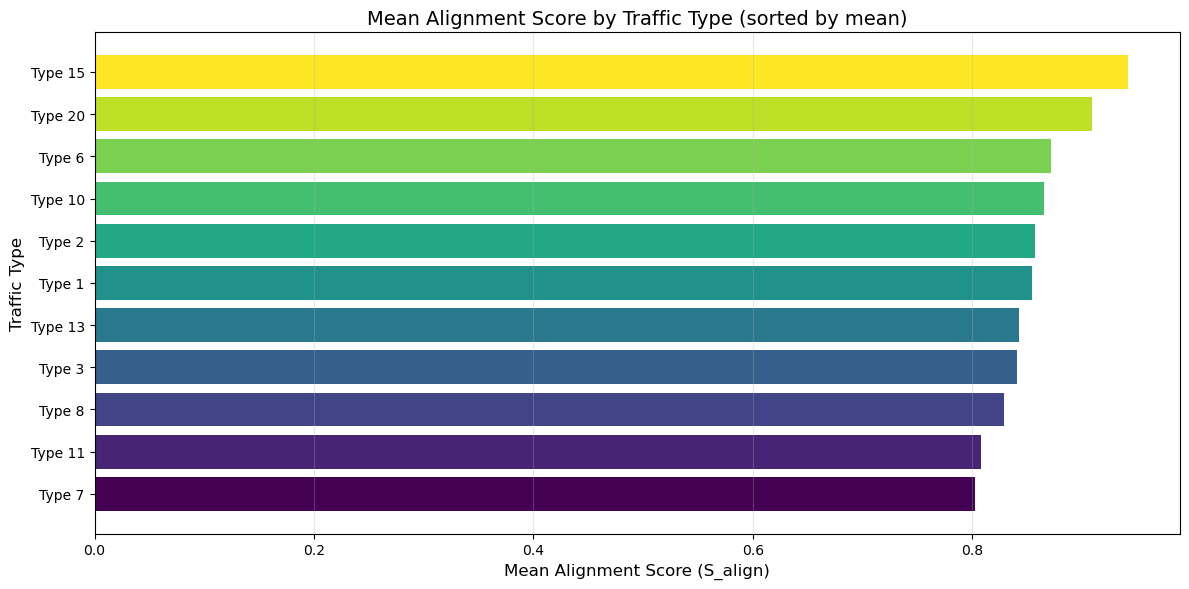


✓ PILLAR 3 evaluation completed


In [28]:
# PILLAR 3 — Contextual Shifts
# Goal: Show how rationality-weighted alignment varies across context

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load alignment metrics
try:
    results_df = pd.read_parquet('data/processed/alignment_metrics.parquet')
except Exception:
    results_df = pd.read_csv('data/processed/alignment_metrics.csv')

# Load original dataset and get validation rows (assume last n_val rows)
df_original = pd.read_csv('data/online_shoppers_intention.csv')
n_val = len(results_df)
df_context = df_original.iloc[-n_val:][['Weekend', 'Month', 'TrafficType']].reset_index(drop=True)
df_combined = pd.concat([results_df.reset_index(drop=True), df_context], axis=1)

print("\n" + "="*60)
print("PILLAR 3 — Contextual Shifts")
print("="*60)

# 1) Weekend vs Weekday (boxplot)
print("\n1. Weekend vs Weekday Analysis:")
weekend_summary = df_combined.groupby('Weekend')['S_align'].agg(['mean', 'median', 'count'])
print(weekend_summary)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_combined, x='Weekend', y='S_align', palette=['lightblue', 'lightcoral'])
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Alignment Score (S_align)', fontsize=12)
plt.title('Alignment Score Distribution: Weekday vs Weekend', fontsize=14)
plt.xticks([False, True], ['Weekday', 'Weekend'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 2) Month analysis (line plot)
if 'Month' in df_combined.columns:
    print("\n2. Month Analysis:")
    month_summary = df_combined.groupby('Month')['S_align'].agg(['mean', 'median', 'count']).reset_index()
    month_summary = month_summary.sort_values('mean')
    print(month_summary.sort_values('mean', ascending=False))
    
    plt.figure(figsize=(10, 6))
    plt.plot(month_summary['Month'], month_summary['mean'], marker='o', linewidth=2, markersize=8)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Mean Alignment Score (S_align)', fontsize=12)
    plt.title('Mean Alignment Score by Month', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n2. Month column not found")

# 3) TrafficType analysis (bar chart)
if 'TrafficType' in df_combined.columns:
    print("\n3. TrafficType Analysis:")
    traffic_summary = df_combined.groupby('TrafficType')['S_align'].agg(['mean', 'median', 'count']).reset_index()
    traffic_summary = traffic_summary.sort_values('mean')
    print(traffic_summary.sort_values('mean', ascending=False))
    
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(traffic_summary)), traffic_summary['mean'], 
             color=plt.cm.viridis(np.linspace(0, 1, len(traffic_summary))))
    plt.yticks(range(len(traffic_summary)), [f'Type {t}' for t in traffic_summary['TrafficType']])
    plt.xlabel('Mean Alignment Score (S_align)', fontsize=12)
    plt.ylabel('Traffic Type', fontsize=12)
    plt.title('Mean Alignment Score by Traffic Type (sorted by mean)', fontsize=14)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print("\n3. TrafficType column not found")

print("\n" + "="*60)
print("✓ PILLAR 3 evaluation completed")
print("="*60)


PILLAR 4 — Feature Monotonicity

Analyzing 5 features: ['PageValues', 'BounceRates', 'ExitRates', 'ProductRelated', 'ProductRelated_Duration']

1. Feature: PageValues
  Binned summary:
   bin      mean  median  count
0    0  0.851094     1.0   1857
1    1  0.858900     1.0    465


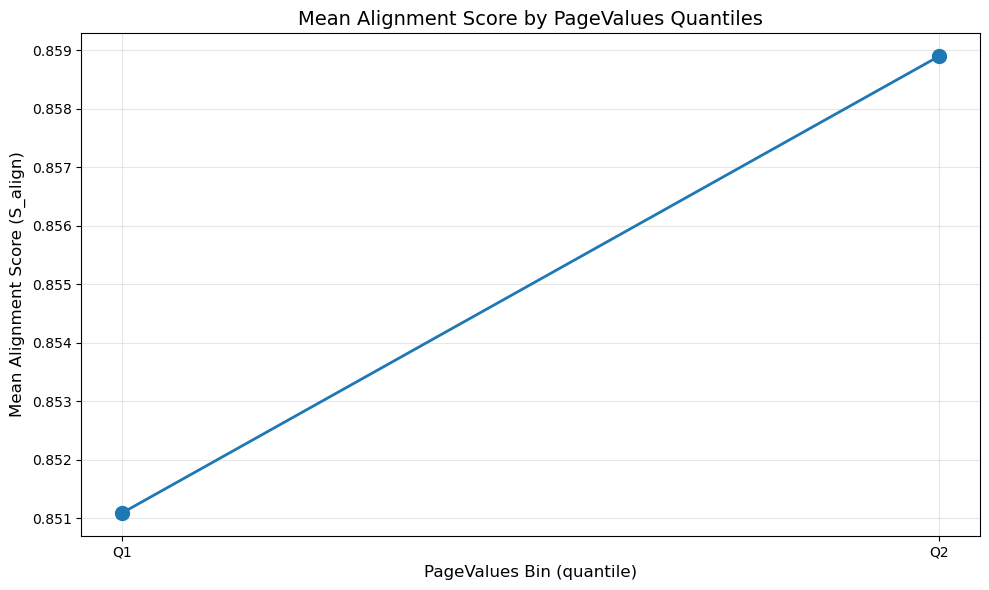


2. Feature: BounceRates
  Binned summary:
   bin      mean  median  count
0    0  0.854411     1.0   1399
1    1  0.857590     1.0    472
2    2  0.842055     1.0    451


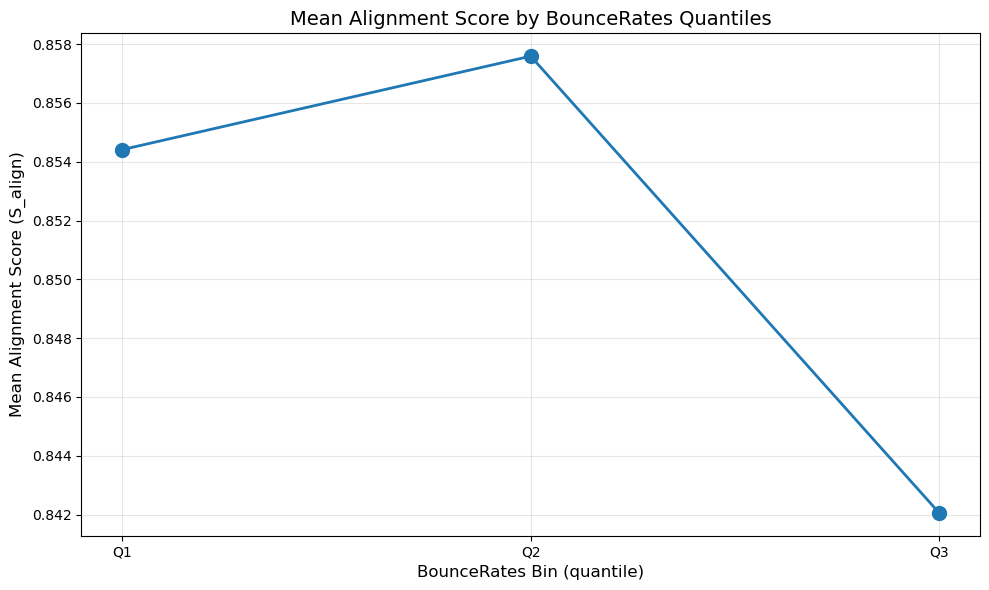


3. Feature: ExitRates
  Binned summary:
   bin      mean  median  count
0    0  0.832070     1.0    465
1    1  0.856468     1.0    466
2    2  0.863077     1.0    462
3    3  0.857596     1.0    499
4    4  0.853865     1.0    430


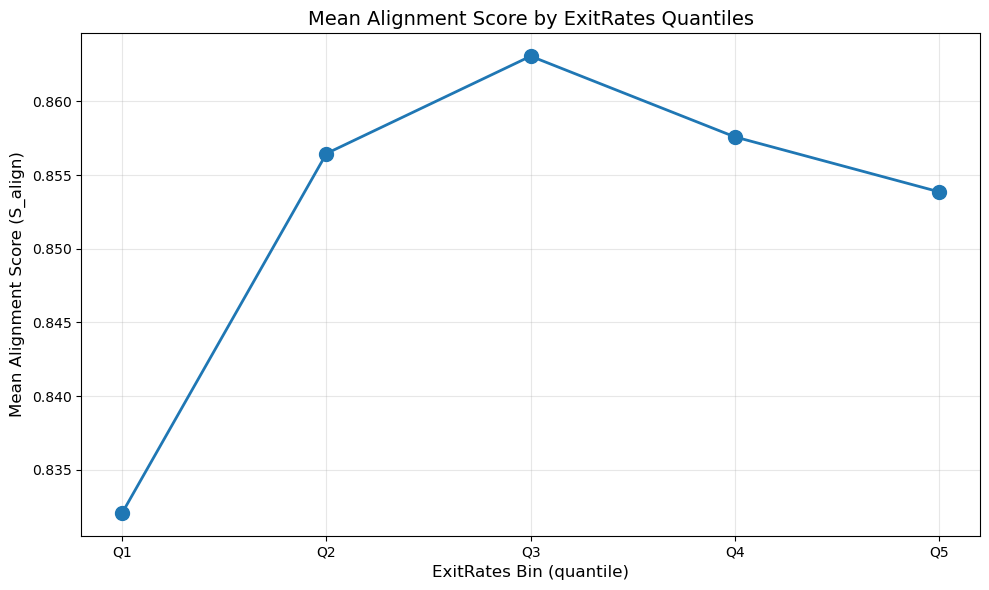


4. Feature: ProductRelated
  Binned summary:
   bin      mean  median  count
0    0  0.861965     1.0    521
1    1  0.853784     1.0    440
2    2  0.839442     1.0    434
3    3  0.859806     1.0    472
4    4  0.846100     1.0    455


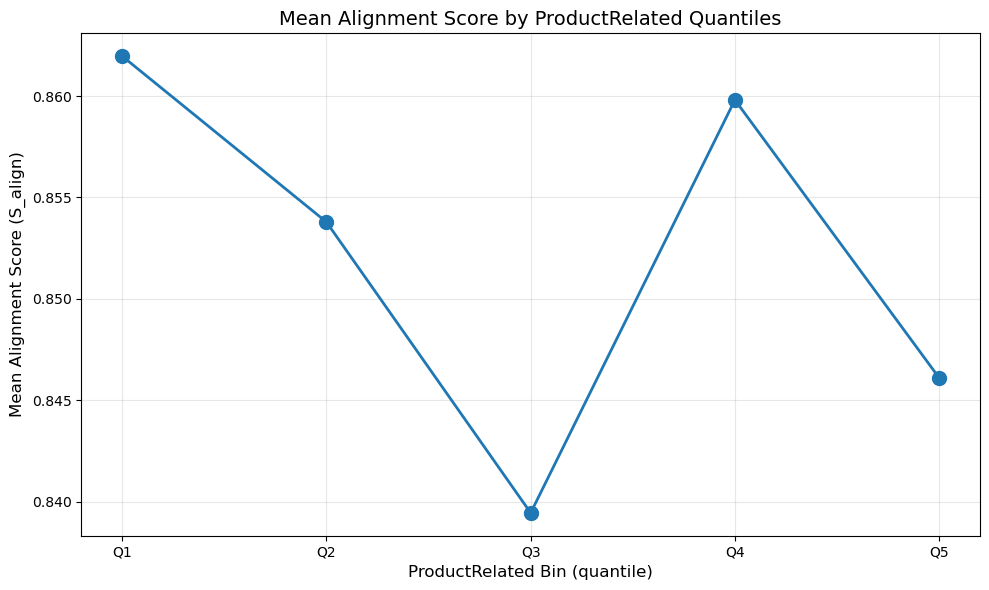


5. Feature: ProductRelated_Duration
  Binned summary:
   bin      mean  median  count
0    0  0.858979     1.0    466
1    1  0.850072     1.0    463
2    2  0.845212     1.0    464
3    3  0.864925     1.0    464
4    4  0.844083     1.0    465


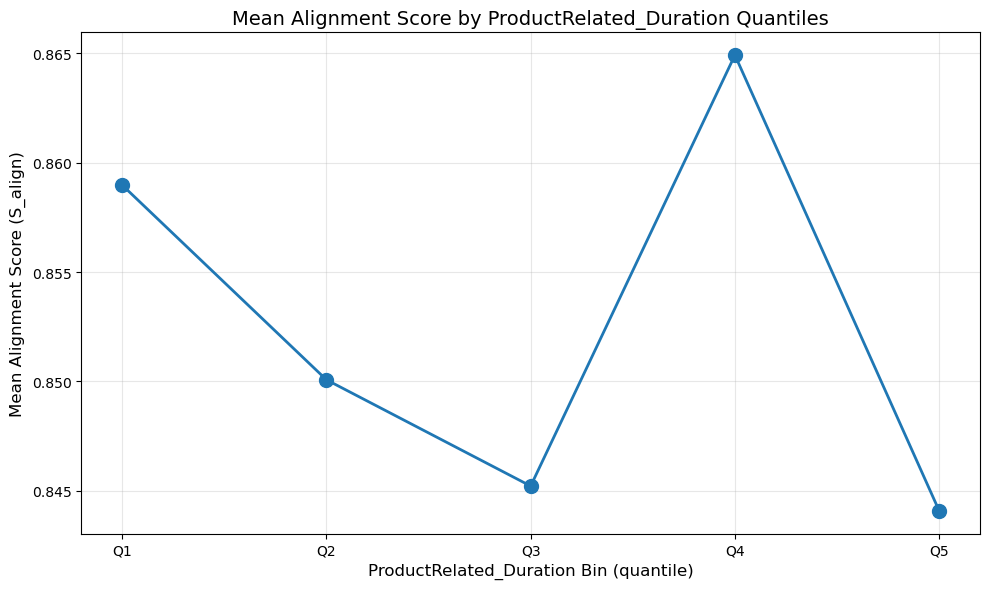


✓ PILLAR 4 evaluation completed


In [29]:
# PILLAR 4 — Feature Monotonicity
# Goal: Verify that alignment behaves monotonically with intuitive intent-related features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load alignment metrics
try:
    results_df = pd.read_parquet('data/processed/alignment_metrics.parquet')
except Exception:
    results_df = pd.read_csv('data/processed/alignment_metrics.csv')

# Load original dataset and get feature columns
df_original = pd.read_csv('data/online_shoppers_intention.csv')
n_val = len(results_df)
features_to_check = ['PageValues', 'BounceRates', 'ExitRates', 'ProductRelated', 'ProductRelated_Duration']
df_features = df_original.iloc[-n_val:][features_to_check].reset_index(drop=True)
df_combined = pd.concat([results_df.reset_index(drop=True), df_features], axis=1)

print("\n" + "="*60)
print("PILLAR 4 — Feature Monotonicity")
print("="*60)

# Check which features exist
features_available = [f for f in features_to_check if f in df_combined.columns]
features_missing = [f for f in features_to_check if f not in df_combined.columns]

if features_missing:
    print(f"\nNote: Features not found: {features_missing}")

print(f"\nAnalyzing {len(features_available)} features: {features_available}")

# For each feature, bin into quantiles and compute mean S_align
n_bins = 5

for i, feature in enumerate(features_available):
    print(f"\n{i+1}. Feature: {feature}")
    
    # Remove NaN values
    df_feat = df_combined[[feature, 'S_align']].dropna()
    
    if len(df_feat) < n_bins:
        print(f"  Warning: Not enough values ({len(df_feat)}) for {n_bins} bins, skipping")
        continue
    
    # Bin into quantiles
    try:
        df_feat['bin'] = pd.qcut(df_feat[feature], q=n_bins, duplicates='drop', labels=False)
    except ValueError:
        print(f"  Warning: Could not create quantile bins, skipping")
        continue
    
    # Compute summary per bin
    bin_summary = df_feat.groupby('bin')['S_align'].agg(['mean', 'median', 'count']).reset_index()
    bin_summary = bin_summary.sort_values('bin')
    
    print(f"  Binned summary:")
    print(bin_summary)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(bin_summary['bin'], bin_summary['mean'], marker='o', markersize=10, linewidth=2)
    plt.xlabel(f'{feature} Bin (quantile)', fontsize=12)
    plt.ylabel('Mean Alignment Score (S_align)', fontsize=12)
    plt.title(f'Mean Alignment Score by {feature} Quantiles', fontsize=14)
    plt.xticks(bin_summary['bin'], [f'Q{i+1}' for i in range(len(bin_summary))])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("✓ PILLAR 4 evaluation completed")
print("="*60)


PILLAR 5 — Calibration-style Check
λ̂ (rationality parameter): 0.973386

Predicted probabilities:
  Range: [0.014449, 1.000000]
  Mean: 0.496863

Calibration Table:
 bin  mean_predicted_prob  observed_purchase_rate  mean_s_align  n_samples
   0             0.067060                0.007812      0.992685        128
   1             0.163110                0.004975      0.995997        201
   2             0.265129                0.011407      0.993220        263
   3             0.360366                0.037249      0.984537        349
   4             0.459174                0.042424      0.994105        330
   5             0.555949                0.115385      0.831273        286
   6             0.655517                0.190871      0.620972        241
   7             0.747407                0.270936      0.519265        203
   8             0.852160                0.555556      0.635363        126
   9             0.970494                0.743590      0.753185        195


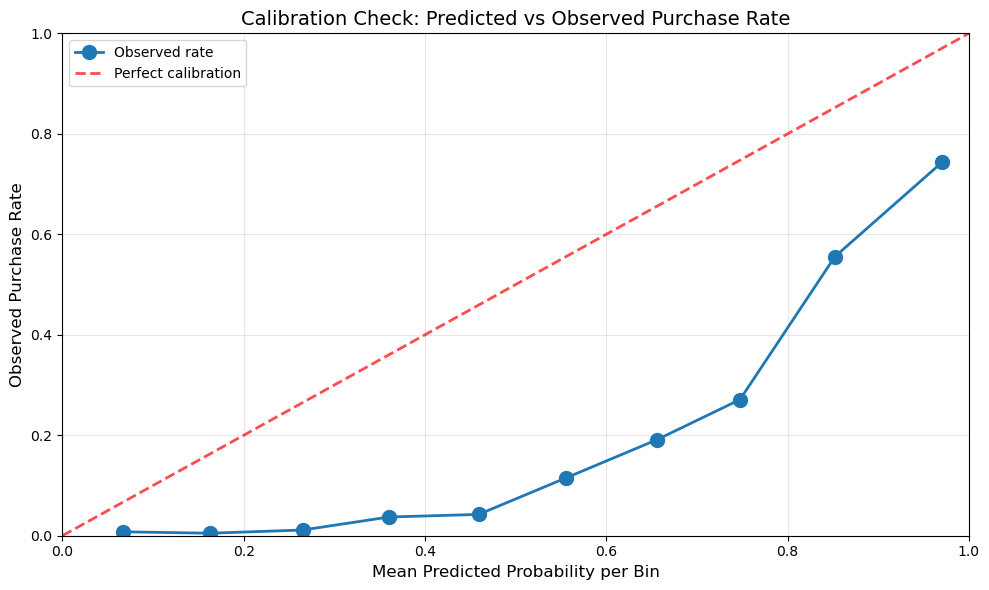

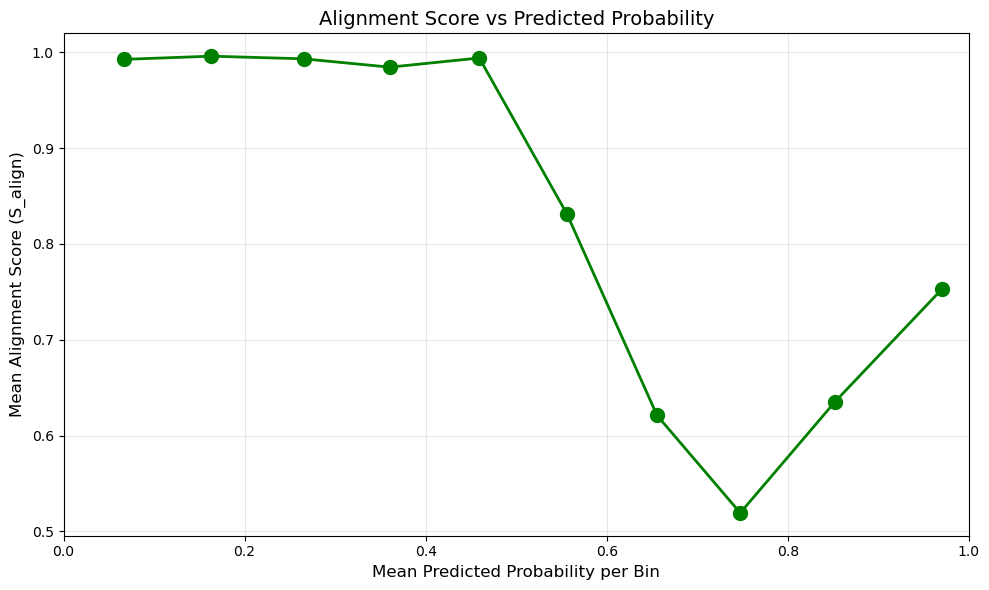


✓ PILLAR 5 evaluation completed


In [30]:
# PILLAR 5 — Calibration-style Check
# Goal: Check whether alignment decreases when high-confidence predictions are contradicted

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Load alignment metrics
try:
    results_df = pd.read_parquet('data/processed/alignment_metrics.parquet')
except Exception:
    results_df = pd.read_csv('data/processed/alignment_metrics.csv')

# Load rationality parameter
with open('data/processed/rationality_temperature.pkl', 'rb') as f:
    lambda_hat = pickle.load(f)['lambda_hat']

V = results_df['V'].values
y_val = results_df['Revenue'].values

print("\n" + "="*60)
print("PILLAR 5 — Calibration-style Check")
print("="*60)
print(f"λ̂ (rationality parameter): {lambda_hat:.6f}")

# Compute predicted purchase probability: p = sigmoid(lambda_hat * V)
z = np.clip(lambda_hat * V, -500, 500)  # Clip to avoid overflow
p_pred = 1.0 / (1.0 + np.exp(-z))

print(f"\nPredicted probabilities:")
print(f"  Range: [{p_pred.min():.6f}, {p_pred.max():.6f}]")
print(f"  Mean: {p_pred.mean():.6f}")

# Bin into confidence bins and compute summaries
results_df['p_pred'] = p_pred
results_df['bin'] = pd.cut(p_pred, bins=10, labels=False, include_lowest=True)

calibration_df = results_df.groupby('bin').agg({
    'p_pred': 'mean',
    'Revenue': 'mean',  # Observed purchase rate
    'S_align': 'mean',
    'V': 'count'  # Sample count
}).reset_index()
calibration_df.columns = ['bin', 'mean_predicted_prob', 'observed_purchase_rate', 'mean_s_align', 'n_samples']
calibration_df = calibration_df.sort_values('mean_predicted_prob')

print("\nCalibration Table:")
print(calibration_df.to_string(index=False))

# Plot 1: Predicted vs Observed purchase rate
plt.figure(figsize=(10, 6))
plt.plot(calibration_df['mean_predicted_prob'], calibration_df['observed_purchase_rate'], 
         marker='o', markersize=10, linewidth=2, label='Observed rate')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration', alpha=0.7)
plt.xlabel('Mean Predicted Probability per Bin', fontsize=12)
plt.ylabel('Observed Purchase Rate', fontsize=12)
plt.title('Calibration Check: Predicted vs Observed Purchase Rate', fontsize=14)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Alignment score vs predicted probability
plt.figure(figsize=(10, 6))
plt.plot(calibration_df['mean_predicted_prob'], calibration_df['mean_s_align'], 
         marker='o', markersize=10, linewidth=2, color='green')
plt.xlabel('Mean Predicted Probability per Bin', fontsize=12)
plt.ylabel('Mean Alignment Score (S_align)', fontsize=12)
plt.title('Alignment Score vs Predicted Probability', fontsize=14)
plt.xlim([0, 1])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✓ PILLAR 5 evaluation completed")
print("="*60)